# Phase 2: Semantic features and missingness

Phase 1 only used structural features. Tran et al. push the model further with semantic metadata pulled from raw APKs via Androguard, but extracting that from APKs is too heavy for Colab Pro, cause it would mean running static analysis on every binary. So we use surrogate graph derived features in place of real metadata. The paper limitations section calls this out honestly.

The surrogate semantic block adds 9 more dimensions on top of phase 1's 11 structural ones, for 20 total per node. The 9 extras are motif counts, degree quantile bins, and 2 hop neighborhood size. We keep the structural columns first and the semantic ones after, that way we can tell them apart when simulating missingness.

At training time only, we randomly drop the semantic group with probability 0.5 per graph and try two ways to handle the missing chunk:
- zero fill: just set those columns to zero
- prune: same as zero fill in this experiment, cause real node pruning would break batching

Train EnrichedGCN once per strategy and compare. The mask itself is not used by the model in this phase, that comes in phase 3.


## 1. Setup


In [1]:
import os
REPO = "malnet-shift-robustness"
if not os.path.exists(REPO):
    !git clone https://github.com/AdityaRao127/malnet-shift-robustness.git
%cd $REPO


Cloning into 'malnet-shift-robustness'...
remote: Enumerating objects: 63, done.
remote: Counting objects: 100% (63/63), done.
remote: Compressing objects: 100% (32/32), done.
remote: Total 63 (delta 28), reused 62 (delta 27), pack-reused 0 (from 0)
Receiving objects: 100% (63/63), 171.05 KiB | 24.44 MiB/s, done.
Resolving deltas: 100% (28/28), done.
/content/malnet-shift-robustness


In [2]:
!pip install -q torch-geometric==2.7.0 scikit-learn pandas matplotlib tqdm numpy


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 62.7 MB/s eta 0:00:00


In [3]:
import os, sys, time, random, json, copy
sys.path.insert(0, "src")

import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

from torch_geometric.loader import DataLoader

from data_loader import load_malnet_splits
from features import make_pre_transform, ENRICHED_GROUPS
from missingness import make_missingness_transform
from model import EnrichedGCN
from train import train_model, predict, build_metrics, save_metrics

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"using device: {device}")


using device: cuda


## 2. Hyperparameters


In [4]:
EPOCHS = 50
LR = 0.001
BATCH_SIZE = 64
HIDDEN_DIM = 64
DROP_PROB = 0.5
RESULTS_DIR = "results"
os.makedirs(RESULTS_DIR, exist_ok=True)


## 3. Load Dataset with Enriched Features

Cache lives at data/enriched/ to avoid colliding with the structural cache from phase 1.


In [5]:
pre_transform = make_pre_transform(feature_type="enriched")
train_ds, val_ds, test_ds = load_malnet_splits(
    root="data/enriched/", pre_transform=pre_transform
)

print(f"train: {len(train_ds)} | val: {len(val_ds)} | test: {len(test_ds)}")
print(f"features per node: {train_ds.num_features}")
print(f"groups: {ENRICHED_GROUPS}")

raw_type_dir = os.path.join("data", "enriched", "raw", "split_info_tiny", "type")
y_map = {}
for split_file in ["train.txt", "val.txt", "test.txt"]:
    with open(os.path.join(raw_type_dir, split_file)) as f:
        for line in f.read().strip().split("\n"):
            mtype = line.split("/")[0]
            y_map.setdefault(mtype, len(y_map))
CLASS_NAMES = [name for name, _ in sorted(y_map.items(), key=lambda x: x[1])]
print(f"classes: {CLASS_NAMES}")


Extracting data/enriched/raw/malnet-graphs-tiny.tar.gz
Extracting data/enriched/raw/split_info_tiny.zip
Processing...
Done!


train: 3500 | val: 500 | test: 1000
features per node: 20
groups: {'structural': (0, 11), 'semantic': (11, 20)}
classes: ['adware', 'benign', 'downloader', 'trojan', 'addisplay']


## 4. Helper: Train + Eval One Strategy


In [6]:
def run_strategy(strategy, prefix):
    # builds loaders with the right missingness transform, trains, saves metrics
    miss_train = make_missingness_transform(ENRICHED_GROUPS, drop_prob=DROP_PROB, strategy=strategy, seed=SEED)
    # pyg DataLoader applies dataset.transform per sample, set on the dataset object
    train_ds.transform = miss_train
    val_ds.transform = None  # no missingness at val/test
    test_ds.transform = None

    # pinned generator so zero and prune runs see the same shuffle order, fair ablation
    g = torch.Generator()
    g.manual_seed(SEED)
    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, generator=g)
    val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)
    test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)

    model = EnrichedGCN(
        in_channels=train_ds.num_features,
        hidden_channels=HIDDEN_DIM,
        num_classes=train_ds.num_classes,
    ).to(device)

    t0 = time.time()
    model, train_losses, val_accs, best_val_acc = train_model(
        model, train_loader, val_loader, EPOCHS, LR, device, verbose_every=10
    )
    train_time = time.time() - t0
    print(f"[{strategy}] training {train_time:.1f}s, best val {best_val_acc:.4f}")

    test_preds, test_labels = predict(model, test_loader, device)
    print(classification_report(test_labels, test_preds, target_names=CLASS_NAMES))

    cfg = {
        "epochs": EPOCHS, "learning_rate": LR, "batch_size": BATCH_SIZE,
        "hidden_dim": HIDDEN_DIM, "drop_prob": DROP_PROB,
        "missingness_strategy": strategy, "feature_type": "enriched",
        "optimizer": "Adam", "device": str(device),
    }
    metrics = build_metrics(test_preds, test_labels, CLASS_NAMES, cfg, best_val_acc, train_time)
    json_path, _ = save_metrics(metrics, RESULTS_DIR, prefix=prefix)
    print("saved", json_path)
    return metrics, train_losses, val_accs, model


## 5. Run Zero-Fill Strategy


In [7]:
metrics_zero, losses_zero, accs_zero, model_zero = run_strategy("zero", "enriched_zero")


  Epoch 010 | Loss: 1.1086 | Val Acc: 0.6780
  Epoch 020 | Loss: 1.0653 | Val Acc: 0.7360
  Epoch 030 | Loss: 1.0062 | Val Acc: 0.7300
  Epoch 040 | Loss: 0.9747 | Val Acc: 0.7000
  Epoch 050 | Loss: 0.9590 | Val Acc: 0.7480
[zero] training 74.3s, best val 0.7540
              precision    recall  f1-score   support

      adware       0.71      0.82      0.76       200
      benign       0.48      0.49      0.49       200
  downloader       0.97      0.99      0.98       200
      trojan       0.88      0.61      0.72       200
   addisplay       0.66      0.71      0.69       200

    accuracy                           0.73      1000
   macro avg       0.74      0.73      0.73      1000
weighted avg       0.74      0.73      0.73      1000

saved results/enriched_zero_metrics.json


## 6. Run Prune Strategy


In [8]:
metrics_prune, losses_prune, accs_prune, model_prune = run_strategy("prune", "enriched_prune")


  Epoch 010 | Loss: 0.8685 | Val Acc: 0.6920
  Epoch 020 | Loss: 0.7957 | Val Acc: 0.7480
  Epoch 030 | Loss: 0.7368 | Val Acc: 0.7380
  Epoch 040 | Loss: 0.7234 | Val Acc: 0.7280
  Epoch 050 | Loss: 0.6674 | Val Acc: 0.7840
[prune] training 71.1s, best val 0.7840
              precision    recall  f1-score   support

      adware       0.70      0.87      0.77       200
      benign       0.52      0.41      0.46       200
  downloader       0.97      0.99      0.98       200
      trojan       0.94      0.60      0.73       200
   addisplay       0.62      0.79      0.69       200

    accuracy                           0.73      1000
   macro avg       0.75      0.73      0.73      1000
weighted avg       0.75      0.73      0.73      1000

saved results/enriched_prune_metrics.json


## 7. Compare Both Strategies


zero-fill:
  accuracy: 0.7280
  f1 macro: 0.7278

prune:
  accuracy: 0.7340
  f1 macro: 0.7279


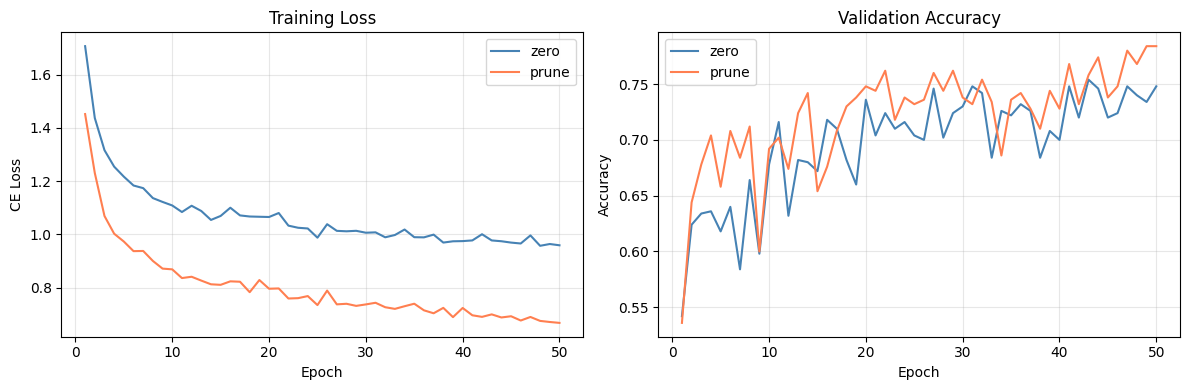

In [9]:
print("zero-fill:")
print(f"  accuracy: {metrics_zero['accuracy']:.4f}")
print(f"  f1 macro: {metrics_zero['f1_macro']:.4f}")
print()
print("prune:")
print(f"  accuracy: {metrics_prune['accuracy']:.4f}")
print(f"  f1 macro: {metrics_prune['f1_macro']:.4f}")

# side by side training curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
epochs = range(1, EPOCHS+1)
ax1.plot(epochs, losses_zero, label="zero", color="steelblue")
ax1.plot(epochs, losses_prune, label="prune", color="coral")
ax1.set_xlabel("Epoch"); ax1.set_ylabel("CE Loss"); ax1.legend(); ax1.set_title("Training Loss"); ax1.grid(alpha=0.3)
ax2.plot(epochs, accs_zero, label="zero", color="steelblue")
ax2.plot(epochs, accs_prune, label="prune", color="coral")
ax2.set_xlabel("Epoch"); ax2.set_ylabel("Accuracy"); ax2.legend(); ax2.set_title("Validation Accuracy"); ax2.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "enriched_compare_curves.png"), dpi=150)
plt.show()


## Summary

Two strategies trained on enriched features with random group drop during training. Metrics go to results/enriched_zero_metrics.json and results/enriched_prune_metrics.json. Phase 3 adds the gating model that actually reads the mask.
